<a href="https://colab.research.google.com/github/lanre-oye/Oyebanji-Olanrewaju-portfolio/blob/main/Data_Analysis_%26_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#step 1 import libraries needed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [ ]:
#step 2 mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#step 3 read your dataset
df = pd.read_csv('/content/Practise_data.csv')
df.head()

,Disaster Subtype,ISO,Country,Subregion,Region,Associated Types,OFDA Response,Start Year,Start Month,End Year,End Month,Total Deaths,No. Affected,Total Affected,CPI
0,Drought,DJI,Djibouti,Sub-Saharan Africa,Africa,Not_Specified,Yes,2001,6.0,2001,0.0,0,100000,100000,60.503579
1,Drought,SDN,Sudan,Northern Africa,Africa,Food shortage|Water shortage,No,2000,1.0,2001,0.0,0,2000000,2000000,58.840648
2,Drought,SOM,Somalia,Sub-Saharan Africa,Africa,Food shortage,No,2000,1.0,2001,0.0,21,1200000,1200000,58.840648
3,Drought,MDG,Madagascar,Sub-Saharan Africa,Africa,Not_Specified,No,2000,6.0,2000,0.0,0,231290,231290,58.840648
4,Drought,BFA,Burkina Faso,Sub-Saharan Africa,Africa,Not_Specified,No,2001,4.0,2001,0.0,0,0,0,60.503579


#Univariate Analysis

In [ ]:
df1= df[['Country', 'Total Affected']]
df1.head()

,Country,Total Affected
0,Djibouti,100000
1,Sudan,2000000
2,Somalia,1200000
3,Madagascar,231290
4,Burkina Faso,0


In [ ]:
# Box plot
px.box(data_frame= df1, x='Total Affected',title='Total Affected Data Distribution')

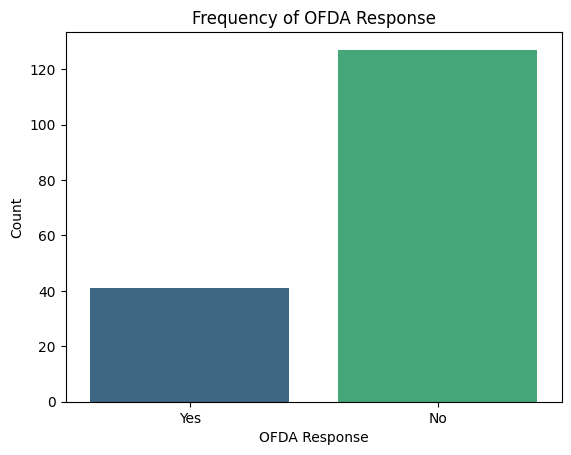

In [ ]:
# response frequency of the united state
sns.countplot(data=df, x='OFDA Response', palette='viridis', hue='OFDA Response', legend=False)
plt.title('Frequency of OFDA Response')
plt.xlabel('OFDA Response')
plt.ylabel('Count')
plt.show()

From the chart above its is seen YES-NO ratio of the UN to African drought occurence is approximately 1:3

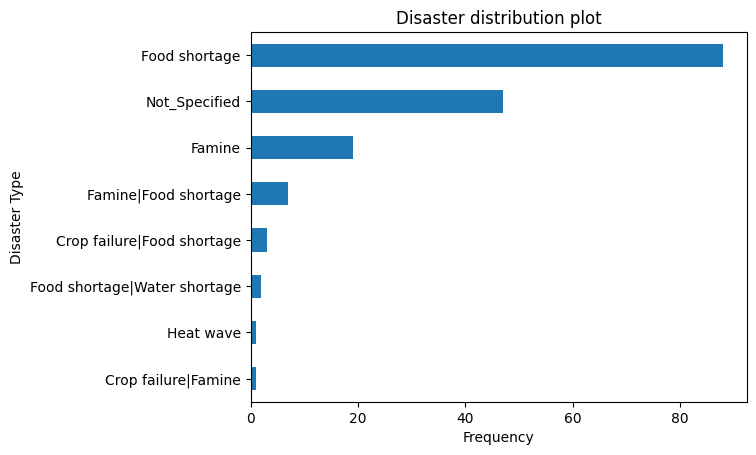

In [ ]:
df['Associated Types'].value_counts().sort_values().plot(kind='barh')
plt.title('Disaster distribution plot')
plt.xlabel('Frequency')
plt.ylabel('Disaster Type')
plt.show()


Its has been observe that the most occuring disaster is food shortage during deought in Africa

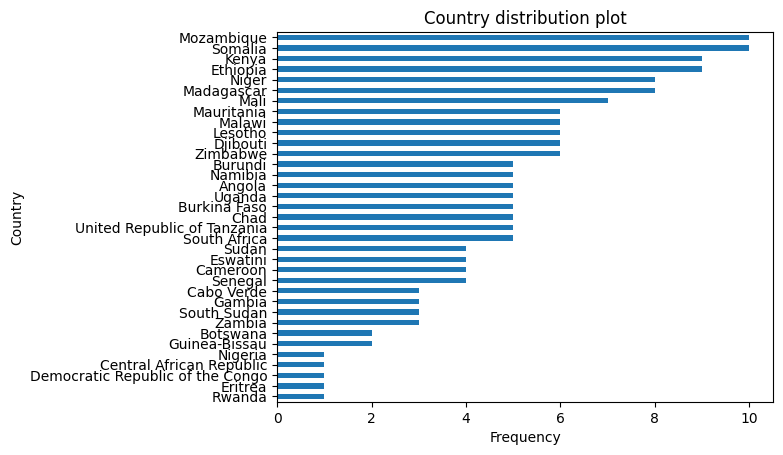

In [ ]:
df['Country'].value_counts().sort_values().plot(kind='barh')
plt.title('Country distribution plot')
plt.xlabel('Frequency')
plt.ylabel('Country')
plt.show()

#Bi-VARIATE Analysis

In [ ]:
Count_by_country = df1.groupby('Country')['Total Affected'].sum().sort_values(ascending=True).reset_index()
px.bar(Count_by_country, x='Total Affected', y='Country', title='Total Affected by Country', orientation='h')

you can use pd.merge to join dataset together
this chart shows eastern africa has more affected area so more aids should be send to eastern and northern africa

In [ ]:
df2 = df[['Subregion', 'Total Affected']]

Count_by_Subregion = df2.groupby('Subregion')['Total Affected'].sum().sort_values(ascending=True).reset_index()
px.pie(Count_by_Subregion, values='Total Affected', names='Subregion', title='Total Affected by Subregion')

In [ ]:
df_mean = df.sort_values(by='Start Year')
df_mean= df_mean.groupby('Start Year').mean(numeric_only=True).reset_index()

In [ ]:
fig = px.line(df_mean, x='Start Year', y='Total Affected', title='Total Affected Over Years')
fig.show()